In [ ]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv, GATConv, Linear
from torch_scatter import scatter_mean
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
class KGModel(nn.Module):
    """
      KG-based Recommendation Model with GAT attention
    """
    
    def __init__(self, num_users, num_movies, num_genres, num_occupations, 
                 hidden_dim=128, num_layers=3, dropout=0.2):
        super().__init__()
        
        self.num_users = num_users
        self.num_movies = num_movies
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        #   embeddings
        self.user_embedding = nn.Embedding(num_users, hidden_dim)
        self.movie_embedding = nn.Embedding(num_movies, hidden_dim)
        self.genre_embedding = nn.Embedding(num_genres, hidden_dim)
        self.occupation_embedding = nn.Embedding(num_occupations, hidden_dim)
        
        # Xavier initialization
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.movie_embedding.weight)
        nn.init.xavier_uniform_(self.genre_embedding.weight)
        nn.init.xavier_uniform_(self.occupation_embedding.weight)
        
        # Linear projections for GAT (since GAT expects specific dimensions)
        self.user_proj = nn.Linear(hidden_dim, hidden_dim)
        self.movie_proj = nn.Linear(hidden_dim, hidden_dim)
        
        # Multi-layer graph convolutions
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        for layer_idx in range(num_layers):
            # First layer: SAGE for stability
            if layer_idx == 0:
                conv = HeteroConv({
                    ('user', 'rates', 'movie'): SAGEConv(hidden_dim, hidden_dim),
                    ('movie', 'rated_by', 'user'): SAGEConv(hidden_dim, hidden_dim),
                    ('movie', 'has_genre', 'genre'): SAGEConv(hidden_dim, hidden_dim),
                    ('genre', 'contains', 'movie'): SAGEConv(hidden_dim, hidden_dim),
                    ('user', 'has_occupation', 'occupation'): SAGEConv(hidden_dim, hidden_dim),
                    ('occupation', 'includes', 'user'): SAGEConv(hidden_dim, hidden_dim),
                    ('user', 'similar_to', 'user'): SAGEConv(hidden_dim, hidden_dim),
                    ('movie', 'similar_to', 'movie'): SAGEConv(hidden_dim, hidden_dim),
                }, aggr='mean')
            else:
                # Later layers: GAT with self-loops disabled
                conv = HeteroConv({
                    ('user', 'rates', 'movie'): GATConv(
                        hidden_dim, hidden_dim // 4, heads=4, 
                        add_self_loops=False, concat=True
                    ),
                    ('movie', 'rated_by', 'user'): GATConv(
                        hidden_dim, hidden_dim // 4, heads=4, 
                        add_self_loops=False, concat=True
                    ),
                    ('movie', 'has_genre', 'genre'): SAGEConv(hidden_dim, hidden_dim),
                    ('genre', 'contains', 'movie'): SAGEConv(hidden_dim, hidden_dim),
                    ('user', 'has_occupation', 'occupation'): SAGEConv(hidden_dim, hidden_dim),
                    ('occupation', 'includes', 'user'): SAGEConv(hidden_dim, hidden_dim),
                    ('user', 'similar_to', 'user'): GATConv(
                        hidden_dim, hidden_dim // 4, heads=4, 
                        add_self_loops=False, concat=True
                    ),
                    ('movie', 'similar_to', 'movie'): GATConv(
                        hidden_dim, hidden_dim // 4, heads=4, 
                        add_self_loops=False, concat=True
                    ),
                }, aggr='mean')
            
            self.convs.append(conv)
            self.norms.append(nn.ModuleDict({
                'user': nn.LayerNorm(hidden_dim),
                'movie': nn.LayerNorm(hidden_dim),
                'genre': nn.LayerNorm(hidden_dim),
                'occupation': nn.LayerNorm(hidden_dim),
            }))
        
        # Link predictor
        self.link_predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )
        
        self.dropout = nn.Dropout(dropout)
        self.layer_weights = nn.Parameter(torch.ones(num_layers) / num_layers)
        
    def forward(self, edge_index_dict):
        """Forward pass with layer combination"""
        x_dict = {
            'user': self.user_embedding.weight,
            'movie': self.movie_embedding.weight,
            'genre': self.genre_embedding.weight,
            'occupation': self.occupation_embedding.weight,
        }
        
        # Filter valid edges
        valid_edge_dict = {}
        for edge_type, edge_index in edge_index_dict.items():
            if edge_index is not None and edge_index.numel() > 0:
                valid_edge_dict[edge_type] = edge_index
        
        layer_embeddings = []
        
        for i, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            if len(valid_edge_dict) > 0:
                x_dict_new = conv(x_dict, valid_edge_dict)
            else:
                x_dict_new = x_dict
            
            # Apply normalization and activation
            for node_type in x_dict_new:
                if node_type in norm_dict:
                    x_dict_new[node_type] = norm_dict[node_type](x_dict_new[node_type])
                x_dict_new[node_type] = F.leaky_relu(x_dict_new[node_type], 0.2)
                x_dict_new[node_type] = self.dropout(x_dict_new[node_type])
            
            # Residual connection
            if i > 0:
                for node_type in x_dict_new:
                    if node_type in x_dict:
                        x_dict_new[node_type] = x_dict_new[node_type] + x_dict[node_type]
            
            x_dict = x_dict_new
            layer_embeddings.append({
                'user': x_dict['user'].clone(),
                'movie': x_dict['movie'].clone()
            })
        
        # Weighted combination
        weights = F.softmax(self.layer_weights, dim=0)
        final_user_emb = sum(w * emb['user'] for w, emb in zip(weights, layer_embeddings))
        final_movie_emb = sum(w * emb['movie'] for w, emb in zip(weights, layer_embeddings))
        
        return {
            'user': final_user_emb,
            'movie': final_movie_emb,
            'genre': x_dict.get('genre', self.genre_embedding.weight),
            'occupation': x_dict.get('occupation', self.occupation_embedding.weight)
        }
    
    def predict_link(self, user_emb, movie_emb):
        """Predict interaction probability"""
        return self.link_predictor(torch.cat([user_emb, movie_emb], dim=-1))

In [ ]:
class ImprovedMovieLensDataLoader:
    """  data loader with better graph construction"""
    
    def __init__(self, data_path='ml-100k'):
        self.data_path = data_path
        
    def load_all_data(self):
        """Load all MovieLens data files"""
        print("Loading MovieLens 100K dataset...")
        
        # Load ratings
        self.train_ratings = pd.read_csv(
            f'{self.data_path}/ua.base', 
            sep='\t',
            names=['user_id', 'movie_id', 'rating', 'timestamp']
        )
        
        self.test_ratings = pd.read_csv(
            f'{self.data_path}/ua.test',
            sep='\t', 
            names=['user_id', 'movie_id', 'rating', 'timestamp']
        )
        
        # Load movie metadata
        movie_cols = ['movie_id', 'title', 'release_date', 'video_release', 
                     'imdb_url'] + [f'genre_{i}' for i in range(19)]
        self.movies = pd.read_csv(
            f'{self.data_path}/u.item',
            sep='|',
            encoding='latin-1',
            names=movie_cols
        )
        
        # Load genre names
        with open(f'{self.data_path}/u.genre', 'r') as f:
            self.genre_names = [line.split('|')[0] for line in f.read().strip().split('\n')]
        
        # Load user demographics
        self.users = pd.read_csv(
            f'{self.data_path}/u.user',
            sep='|',
            names=['user_id', 'age', 'gender', 'occupation', 'zip']
        )
        
        with open(f'{self.data_path}/u.occupation', 'r') as f:
            self.occupation_names = [line.strip() for line in f.readlines()]
        
        self.occupation_to_idx = {occ: idx for idx, occ in enumerate(self.occupation_names)}
        
        print(f"Loaded: {len(self.train_ratings)} train ratings, {len(self.test_ratings)} test ratings")
        print(f"Movies: {len(self.movies)}, Users: {len(self.users)}")
        
        return self
    
    def build_heterogeneous_graph(self, rating_threshold=3):
        """Build   heterogeneous graph with collaborative edges"""
        print("\nBuilding   heterogeneous knowledge graph...")
        
        data = HeteroData()
        
        # Node counts
        self.num_users = self.users['user_id'].max()
        self.num_movies = self.movies['movie_id'].max()
        self.num_genres = len(self.genre_names)
        self.num_occupations = len(self.occupation_names)
        
        data['user'].num_nodes = self.num_users
        data['movie'].num_nodes = self.num_movies
        data['genre'].num_nodes = self.num_genres
        data['occupation'].num_nodes = self.num_occupations
        
        # Build user-movie interaction matrix for collaborative edges
        all_ratings = pd.concat([self.train_ratings, self.test_ratings])
        
        # User-Movie edges (all ratings for training, but we'll use positive ones)
        positive_ratings = self.train_ratings[self.train_ratings['rating'] >= rating_threshold]
        user_movie_edges = torch.tensor([
            positive_ratings['user_id'].values - 1,
            positive_ratings['movie_id'].values - 1
        ], dtype=torch.long)
        
        data['user', 'rates', 'movie'].edge_index = user_movie_edges
        data['movie', 'rated_by', 'user'].edge_index = user_movie_edges.flip(0)
        
        # Store positive pairs
        self.all_positive_pairs = set(
            zip(positive_ratings['user_id'].values - 1,
                positive_ratings['movie_id'].values - 1)
        )
        
        # Build user-item interaction matrix for similarity computation
        user_item_matrix = np.zeros((self.num_users, self.num_movies))
        for _, row in positive_ratings.iterrows():
            user_item_matrix[row['user_id'] - 1, row['movie_id'] - 1] = 1
        
        # User-User edges (collaborative filtering signal)
        print("  Computing user-user similarities...")
        user_similarity = cosine_similarity(user_item_matrix)
        np.fill_diagonal(user_similarity, 0)
        
        user_user_edges = []
        for i in range(self.num_users):
            # Top 5 similar users
            top_similar = np.argsort(user_similarity[i])[-5:]
            for j in top_similar:
                if user_similarity[i, j] > 0.1:  # Similarity threshold
                    user_user_edges.append([i, j])
        
        if user_user_edges:
            user_user_edges = torch.tensor(user_user_edges, dtype=torch.long).t()
            data['user', 'similar_to', 'user'].edge_index = user_user_edges
            print(f"  Added {user_user_edges.shape[1]} user-user edges")
        
        # Movie-Movie edges (content-based and collaborative)
        print("  Computing movie-movie similarities...")
        movie_item_matrix = user_item_matrix.T
        movie_collab_similarity = cosine_similarity(movie_item_matrix)
        
        movie_genre_matrix = self.movies.iloc[:, 5:].values
        movie_content_similarity = cosine_similarity(movie_genre_matrix)
        
        # Combine similarities
        movie_similarity = 0.6 * movie_collab_similarity + 0.4 * movie_content_similarity
        np.fill_diagonal(movie_similarity, 0)
        
        movie_movie_edges = []
        for i in range(self.num_movies):
            top_similar = np.argsort(movie_similarity[i])[-5:]
            for j in top_similar:
                if movie_similarity[i, j] > 0.1:
                    movie_movie_edges.append([i, j])
        
        if movie_movie_edges:
            movie_movie_edges = torch.tensor(movie_movie_edges, dtype=torch.long).t()
            data['movie', 'similar_to', 'movie'].edge_index = movie_movie_edges
            print(f"  Added {movie_movie_edges.shape[1]} movie-movie edges")
        
        # Movie-Genre edges
        movie_genre_edges = []
        for _, row in self.movies.iterrows():
            movie_id = row['movie_id'] - 1
            for genre_idx in range(self.num_genres):
                if row[f'genre_{genre_idx}'] == 1:
                    movie_genre_edges.append([movie_id, genre_idx])
        
        movie_genre_edges = torch.tensor(movie_genre_edges, dtype=torch.long).t()
        data['movie', 'has_genre', 'genre'].edge_index = movie_genre_edges
        data['genre', 'contains', 'movie'].edge_index = movie_genre_edges.flip(0)
        
        # User-Occupation edges
        user_occ_edges = []
        for _, row in self.users.iterrows():
            occ_idx = self.occupation_to_idx.get(row['occupation'], 0)
            user_occ_edges.append([row['user_id'] - 1, occ_idx])
        
        user_occ_edges = torch.tensor(user_occ_edges, dtype=torch.long).t()
        data['user', 'has_occupation', 'occupation'].edge_index = user_occ_edges
        data['occupation', 'includes', 'user'].edge_index = user_occ_edges.flip(0)
        
        # Prepare test data
        test_positive = self.test_ratings[self.test_ratings['rating'] >= rating_threshold]
        test_edges = torch.tensor([
            test_positive['user_id'].values - 1,
            test_positive['movie_id'].values - 1
        ], dtype=torch.long)
        
        # User test items
        user_test_items = defaultdict(list)
        for user, movie in test_edges.T.numpy():
            user_test_items[user].append(movie)
        
        # All seen pairs for evaluation
        all_positive = all_ratings[all_ratings['rating'] >= rating_threshold]
        all_seen_pairs = set(
            zip(all_positive['user_id'].values - 1,
                all_positive['movie_id'].values - 1)
        )
        
        print(f"\nHeterogeneous Graph Statistics:")
        print(f"  Users: {data['user'].num_nodes}")
        print(f"  Movies: {data['movie'].num_nodes}")
        print(f"  Genres: {data['genre'].num_nodes}")
        print(f"  Occupations: {data['occupation'].num_nodes}")
        print(f"  User-Movie edges: {data['user', 'rates', 'movie'].edge_index.shape[1]}")
        print(f"  Movie-Genre edges: {data['movie', 'has_genre', 'genre'].edge_index.shape[1]}")
        print(f"  User-Occupation edges: {data['user', 'has_occupation', 'occupation'].edge_index.shape[1]}")
        
        data.all_positive_pairs = self.all_positive_pairs
        data.all_seen_pairs = all_seen_pairs
        
        return data, user_test_items, all_seen_pairs

In [ ]:
class ImprovedTrainer:
    """  trainer with better negative sampling and loss functions"""
    
    def __init__(self, model, device='cpu'):
        self.model = model
        self.device = device
        self.movie_popularity = None
        
    def negative_sampling(self, pos_edges, num_users, num_movies, num_neg=4, 
                          exclude_pairs=None, use_popularity=True):
        """Improved negative sampling with popularity bias"""
        pos_edges_np = pos_edges.cpu().numpy()
        neg_users = []
        neg_movies = []
        
        if use_popularity and self.movie_popularity is not None:
            # Ensure probabilities sum exactly to 1
            pop_probs = self.movie_popularity.cpu().numpy()
            pop_probs = pop_probs / pop_probs.sum()  # Normalize again for safety
        else:
            pop_probs = None
        
        for user, movie in pos_edges_np.T:
            for _ in range(num_neg):
                max_attempts = 100
                for _ in range(max_attempts):
                    if pop_probs is not None:
                        # Use numpy's random choice with validated probabilities
                        try:
                            neg_movie = np.random.choice(num_movies, p=pop_probs)
                        except ValueError:
                            # Fallback to uniform if probabilities are invalid
                            neg_movie = np.random.randint(0, num_movies)
                    else:
                        neg_movie = np.random.randint(0, num_movies)
                    
                    if (user, neg_movie) not in exclude_pairs:
                        neg_users.append(user)
                        neg_movies.append(neg_movie)
                        break
        
        return torch.tensor([neg_users, neg_movies], dtype=torch.long)
    
    def compute_bpr_loss(self, pos_scores, neg_scores, num_neg=4):
        """Bayesian Personalized Ranking loss"""
        if num_neg > 1:
            # Reshape neg_scores to (batch_size, num_neg)
            batch_size = pos_scores.shape[0]
            neg_scores = neg_scores.view(batch_size, num_neg)
            pos_scores_expanded = pos_scores.unsqueeze(1).expand(-1, num_neg)
            loss = -torch.log(torch.sigmoid(pos_scores_expanded - neg_scores) + 1e-10).mean()
        else:
            loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()
        return loss
    
    def compute_infonce_loss(self, user_emb, movie_emb, pos_edges, temperature=0.1):
        """InfoNCE contrastive loss for better representations"""
        batch_users = pos_edges[0]
        batch_movies = pos_edges[1]
        batch_size = len(batch_users)
        
        pos_user_emb = user_emb[batch_users]
        pos_movie_emb = movie_emb[batch_movies]
        
        # L2 normalize embeddings
        pos_user_emb = F.normalize(pos_user_emb, p=2, dim=-1)
        pos_movie_emb = F.normalize(pos_movie_emb, p=2, dim=-1)
        movie_emb_norm = F.normalize(movie_emb, p=2, dim=-1)
        
        # Positive scores
        pos_scores = (pos_user_emb * pos_movie_emb).sum(dim=-1) / temperature  # (batch_size,)
        
        # Negative scores against all movies
        neg_scores = torch.matmul(pos_user_emb, movie_emb_norm.t()) / temperature  # (batch_size, num_movies)
        
        # Exclude positive pairs from negative scores
        # Use scatter to set positive positions to -inf
        mask = torch.ones_like(neg_scores, dtype=torch.bool)
        mask[torch.arange(batch_size, device=neg_scores.device), batch_movies] = False
        
        # Compute loss using the formula: -log(exp(pos) / (exp(pos) + sum(exp(neg))))
        # For numerical stability, we can compute as:
        # pos_scores - log(exp(pos_scores) + sum(exp(neg_scores)))
        
        # Get negative scores only (excluding positives)
        neg_scores_masked = neg_scores[mask].view(batch_size, -1)
        
        # Combine positive and negative scores
        all_scores = torch.cat([pos_scores.unsqueeze(1), neg_scores_masked], dim=1)
        
        # Target is always 0 (the positive is at index 0)
        labels = torch.zeros(batch_size, dtype=torch.long, device=all_scores.device)
        
        loss = F.cross_entropy(all_scores, labels)
        
        return loss
    
    def train_epoch(self, data, optimizer, num_neg=4, batch_size=4096):
        """  training epoch"""
        self.model.train()
        optimizer.zero_grad()
        
        edge_index_dict = {k: v.to(self.device) for k, v in data.edge_index_dict.items()}
        
        # Forward pass
        embeddings = self.model(edge_index_dict)
        
        # Get positive edges
        pos_edges = data['user', 'rates', 'movie'].edge_index
        num_pos = pos_edges.shape[1]
        
        # Sample batch
        if num_pos > batch_size:
            batch_indices = torch.randperm(num_pos)[:batch_size]
            pos_edges_batch = pos_edges[:, batch_indices].to(self.device)
        else:
            pos_edges_batch = pos_edges.to(self.device)
            batch_size = num_pos
        
        # Positive scores
        user_emb_pos = embeddings['user'][pos_edges_batch[0]]
        movie_emb_pos = embeddings['movie'][pos_edges_batch[1]]
        pos_scores = self.model.predict_link(user_emb_pos, movie_emb_pos).squeeze()
        
        # Handle case where batch_size is 1
        if batch_size == 1:
            pos_scores = pos_scores.unsqueeze(0)
        
        # Negative sampling
        neg_edges = self.negative_sampling(
            pos_edges_batch,
            data['user'].num_nodes,
            data['movie'].num_nodes,
            num_neg=num_neg,
            exclude_pairs=data.all_positive_pairs
        ).to(self.device)
        
        user_emb_neg = embeddings['user'][neg_edges[0]]
        movie_emb_neg = embeddings['movie'][neg_edges[1]]
        neg_scores = self.model.predict_link(user_emb_neg, movie_emb_neg).squeeze()
        
        # BPR loss
        bpr_loss = self.compute_bpr_loss(pos_scores, neg_scores, num_neg)
        
        # InfoNCE loss for better representations
        infonce_loss = self.compute_infonce_loss(
            embeddings['user'], embeddings['movie'], pos_edges_batch
        )
        
        # Combined loss
        loss = bpr_loss + 0.1 * infonce_loss
        
        # L2 regularization
        reg_loss = 0
        for param in self.model.parameters():
            reg_loss += 0.00001 * torch.norm(param, p=2)
        loss = loss + reg_loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        optimizer.step()
        
        return loss.item(), bpr_loss.item(), infonce_loss.item()

def  train_model(data, user_test_items, hidden_dim=128, num_layers=3, 
                         num_epochs=100, lr=0.001):
    """Complete training pipeline for   model"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    model = KGModel(
        num_users=data['user'].num_nodes,
        num_movies=data['movie'].num_nodes,
        num_genres=data['genre'].num_nodes,
        num_occupations=data['occupation'].num_nodes,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=0.2
    ).to(device)
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    trainer = ImprovedTrainer(model, device)
    
    # Compute movie popularity for negative sampling
    pos_edges = data['user', 'rates', 'movie'].edge_index
    movie_counts = torch.bincount(pos_edges[1], minlength=data['movie'].num_nodes)
    # Add smoothing and use power 0.75 as in word2vec
    trainer.movie_popularity = (movie_counts.float() + 1).pow(0.75)
    # Normalize and ensure sum is exactly 1
    trainer.movie_popularity = trainer.movie_popularity / trainer.movie_popularity.sum()
    # Clip to avoid numerical issues
    trainer.movie_popularity = torch.clamp(trainer.movie_popularity, min=1e-10)
    trainer.movie_popularity = trainer.movie_popularity / trainer.movie_popularity.sum()
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=10
    )
    
    train_losses = []
    best_val_ndcg = 0
    best_epoch = 0
    patience = 20
    patience_counter = 0
    
    print("\nStarting training...")
    
    for epoch in tqdm(range(num_epochs), desc="Training"):
        loss, bpr_loss, infonce_loss = trainer.train_epoch(data, optimizer, num_neg=4)
        train_losses.append(loss)
        
        # Validation every 5 epochs
        if (epoch + 1) % 5 == 0:
            model.eval()
            with torch.no_grad():
                edge_index_dict = {k: v.to(device) for k, v in data.edge_index_dict.items()}
                embeddings = model(edge_index_dict)
                
                val_users = list(user_test_items.keys())[:100]
                val_ndcg_scores = []
                
                for user_id in val_users:
                    true_items = user_test_items[user_id]
                    if len(true_items) == 0:
                        continue
                    
                    user_emb = embeddings['user'][user_id]
                    movie_embs = embeddings['movie']
                    
                    user_emb_expanded = user_emb.unsqueeze(0).expand(movie_embs.shape[0], -1)
                    scores = model.predict_link(user_emb_expanded, movie_embs).squeeze().cpu().numpy()
                    
                    # Mask training items
                    train_items = [m for u, m in data.all_positive_pairs if u == user_id]
                    if train_items:
                        scores[train_items] = -float('inf')
                    
                    top_10 = np.argsort(scores)[-10:][::-1]
                    
                    dcg = sum(1/np.log2(i+2) for i, item in enumerate(top_10) if item in true_items)
                    idcg = sum(1/np.log2(i+2) for i in range(min(10, len(true_items))))
                    ndcg = dcg / idcg if idcg > 0 else 0
                    val_ndcg_scores.append(ndcg)
                
                val_ndcg = np.mean(val_ndcg_scores) if val_ndcg_scores else 0
                
                print(f"\nEpoch {epoch+1}: Loss={loss:.4f} (BPR={bpr_loss:.4f}, InfoNCE={infonce_loss:.4f}), Val NDCG@10={val_ndcg:.4f}")
                
                scheduler.step(val_ndcg)
                
                if val_ndcg > best_val_ndcg:
                    best_val_ndcg = val_ndcg
                    best_epoch = epoch + 1
                    patience_counter = 0
                    torch.save(model.state_dict(), 'best_kg_model.pth')
                else:
                    patience_counter += 1
                
                if patience_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch+1}")
                    break
    
    # Load best model
    if os.path.exists('best_kg_model.pth'):
        model.load_state_dict(torch.load('best_kg_model.pth'))
    
    return model, train_losses, best_val_ndcg, best_epoch

In [ ]:

@torch.no_grad()
def evaluate_model_ (model, data, user_test_items, k_values=[5, 10, 20], device='cpu'):
    """  evaluation with batch processing"""
    model.eval()
    metrics = {k: {'recall': [], 'ndcg': [], 'hit': []} for k in k_values}
    
    edge_index_dict = {k: v.to(device) for k, v in data.edge_index_dict.items()}
    embeddings = model(edge_index_dict)
    
    for user_id, true_items in tqdm(user_test_items.items(), desc="Evaluating"):
        if len(true_items) == 0:
            continue
        
        user_emb = embeddings['user'][user_id]
        movie_embs = embeddings['movie']
        
        # Compute scores efficiently
        scores = model.predict_link(
            user_emb.unsqueeze(0).expand(movie_embs.shape[0], -1),
            movie_embs
        ).squeeze().cpu().numpy()
        
        # Mask training items
        train_items = [m for u, m in data.all_positive_pairs if u == user_id]
        if train_items:
            scores[train_items] = -float('inf')
        
        top_items = np.argsort(scores)[-max(k_values):][::-1]
        
        for k in k_values:
            recommended = top_items[:k]
            
            recall = len(set(recommended) & set(true_items)) / len(true_items)
            metrics[k]['recall'].append(recall)
            
            hit = 1 if len(set(recommended) & set(true_items)) > 0 else 0
            metrics[k]['hit'].append(hit)
            
            dcg = sum(1/np.log2(i+2) for i, item in enumerate(recommended) if item in true_items)
            idcg = sum(1/np.log2(i+2) for i in range(min(k, len(true_items))))
            ndcg = dcg / idcg if idcg > 0 else 0
            metrics[k]['ndcg'].append(ndcg)
    
    avg_metrics = {}
    for k in k_values:
        avg_metrics[k] = {
            'recall': np.mean(metrics[k]['recall']),
            'ndcg': np.mean(metrics[k]['ndcg']),
            'hit_rate': np.mean(metrics[k]['hit'])
        }
    
    return avg_metrics

In [ ]:
# %% [ADDITION 1] Fix Validation Metric Computation
"""
The current validation uses a small subset (100 users) and doesn't properly
evaluate on the full test set during training. Let's fix this.
"""

@torch.no_grad()
def evaluate_model_fixed(model, data, user_test_items, k_values=[5, 10, 20], device='cpu'):
    """  evaluation with proper masking and batch processing"""
    model.eval()
    metrics = {k: {'recall': [], 'ndcg': [], 'hit': [], 'precision': []} for k in k_values}
    
    edge_index_dict = {k: v.to(device) for k, v in data.edge_index_dict.items()}
    embeddings = model(edge_index_dict)
    
    # Get all training interactions for masking
    train_user_items = defaultdict(set)
    for u, m in data.all_positive_pairs:
        train_user_items[u].add(m)
    
    for user_id, true_items in tqdm(user_test_items.items(), desc="Evaluating"):
        if len(true_items) == 0:
            continue
        
        user_emb = embeddings['user'][user_id]
        movie_embs = embeddings['movie']
        
        # Batch prediction for efficiency
        scores = model.predict_link(
            user_emb.unsqueeze(0).expand(movie_embs.shape[0], -1),
            movie_embs
        ).squeeze().cpu().numpy()
        
        # Mask training items AND test items (for fair evaluation)
        if user_id in train_user_items:
            scores[list(train_user_items[user_id])] = -float('inf')
        
        # Get top-k recommendations
        max_k = max(k_values)
        top_items = np.argsort(scores)[-max_k:][::-1]
        
        true_set = set(true_items)
        
        for k in k_values:
            recommended = top_items[:k]
            recommended_set = set(recommended)
            hits = recommended_set & true_set
            
            # Recall@k
            recall = len(hits) / len(true_set)
            metrics[k]['recall'].append(recall)
            
            # Precision@k
            precision = len(hits) / k
            metrics[k]['precision'].append(precision)
            
            # Hit Rate@k
            hit = 1 if len(hits) > 0 else 0
            metrics[k]['hit'].append(hit)
            
            # NDCG@k
            dcg = sum(1/np.log2(i+2) for i, item in enumerate(recommended) if item in true_set)
            idcg = sum(1/np.log2(i+2) for i in range(min(k, len(true_set))))
            ndcg = dcg / idcg if idcg > 0 else 0
            metrics[k]['ndcg'].append(ndcg)
    
    avg_metrics = {}
    for k in k_values:
        avg_metrics[k] = {
            'recall': np.mean(metrics[k]['recall']),
            'precision': np.mean(metrics[k]['precision']),
            'ndcg': np.mean(metrics[k]['ndcg']),
            'hit_rate': np.mean(metrics[k]['hit'])
        }
    
    return avg_metrics, metrics  # Return both aggregated and per-user metrics

In [ ]:
print("=" * 60)
print("KG-BASED RECOMMENDATION SYSTEM")
print("=" * 60)

# Load data
loader = ImprovedMovieLensDataLoader('ml-100k')
loader.load_all_data()

ENHANCED KG-BASED RECOMMENDATION SYSTEM
Loading MovieLens 100K dataset...
Loaded: 90570 train ratings, 9430 test ratings
Movies: 1682, Users: 943


In [ ]:


# Build   graph
kg_data, user_test_items, all_seen_pairs = loader.build_heterogeneous_graph(rating_threshold=3)
kg_data.all_positive_pairs = loader.all_positive_pairs
kg_data.all_seen_pairs = all_seen_pairs


Building enhanced heterogeneous knowledge graph...
  Computing user-user similarities...
  Added 4715 user-user edges
  Computing movie-movie similarities...
  Added 8406 movie-movie edges

Heterogeneous Graph Statistics:
  Users: 943
  Movies: 1682
  Genres: 19
  Occupations: 21
  User-Movie edges: 74627
  Movie-Genre edges: 2893
  User-Occupation edges: 943


In [ ]:


print("\n" + "=" * 60)
print("Training   KG-GNN Model...")
print("=" * 60)

# Train   model
kg_model, train_losses, best_val_ndcg, best_epoch =  train_model(
    kg_data,
    user_test_items,
    hidden_dim=128,
    num_layers=3,
    num_epochs=200,
    lr=0.001
)

print(f"\nBest model at epoch {best_epoch}")
print(f"Best validation NDCG@10: {best_val_ndcg:.4f}")



Training Enhanced KG-GNN Model...
Using device: cpu
Model parameters: 1,144,708

Starting training...


Training:   2%|▎         | 5/200 [00:09<07:31,  2.31s/it]


Epoch 5: Loss=1.4091 (BPR=0.6916, InfoNCE=7.1185), Val NDCG@10=0.0685


Training:   5%|▌         | 10/200 [00:21<08:41,  2.75s/it]


Epoch 10: Loss=1.3668 (BPR=0.6776, InfoNCE=6.8365), Val NDCG@10=0.0958


...


Epoch 190: Loss=1.1350 (BPR=0.5095, InfoNCE=6.2023), Val NDCG@10=0.1355


Training:  98%|█████████▊| 195/200 [06:51<00:13,  2.80s/it]


Epoch 195: Loss=1.1242 (BPR=0.5023, InfoNCE=6.1654), Val NDCG@10=0.1299


Training: 100%|██████████| 200/200 [07:02<00:00,  2.11s/it]


Epoch 200: Loss=1.1339 (BPR=0.5099, InfoNCE=6.1863), Val NDCG@10=0.1421

Best model at epoch 150
Best validation NDCG@10: 0.1627


In [ ]:

# Evaluate
print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\n1.   KG-GNN Model:")
kg_metrics = evaluate_model_ (
    kg_model, kg_data, user_test_items, 
    k_values=[5, 10, 20], device=device
)
for k, metrics in kg_metrics.items():
    print(f"  k={k:2d}: Recall={metrics['recall']:.4f}, "
            f"NDCG={metrics['ndcg']:.4f}, Hit={metrics['hit_rate']:.4f}")


FINAL EVALUATION ON TEST SET

1. Enhanced KG-GNN Model:


Evaluating: 100%|██████████| 943/943 [00:21<00:00, 42.94it/s]

  k= 5: Recall=0.0925, NDCG=0.1684, Hit=0.5451
  k=10: Recall=0.1591, NDCG=0.1647, Hit=0.7116
  k=20: Recall=0.2566, NDCG=0.2149, Hit=0.8505


In [25]:
# %% [ADDITION 2] Complete Baseline Models and Execute Comparison
"""
Implement and evaluate all baseline models for fair comparison
"""

class PopularityBaseline:
    """Recommend most popular items based on training data"""
    
    def __init__(self, train_ratings, rating_threshold=3):
        positive_ratings = train_ratings[train_ratings['rating'] >= rating_threshold]
        self.item_popularity = positive_ratings['movie_id'].value_counts()
        self.popular_items = self.item_popularity.index.values - 1  # 0-indexed
        
    def recommend(self, user_id, k=10, exclude_items=None):
        recommendations = []
        for item in self.popular_items:
            if exclude_items is None or item not in exclude_items:
                recommendations.append(item)
                if len(recommendations) >= k:
                    break
        return recommendations




class ContentBasedBaseline:
    """Content-based recommendation using genre similarity"""
    
    def __init__(self, movies_df, train_ratings, num_users, num_movies, rating_threshold=3):
        # Build movie genre matrix
        self.movie_genres = movies_df.iloc[:, 5:].values.astype(float)
        
        # Build user profiles based on genre preferences
        self.user_profiles = np.zeros((num_users, self.movie_genres.shape[1]))
        positive_ratings = train_ratings[train_ratings['rating'] >= rating_threshold]
        
        for _, row in positive_ratings.iterrows():
            user_idx = row['user_id'] - 1
            movie_idx = row['movie_id'] - 1
            self.user_profiles[user_idx] += self.movie_genres[movie_idx]
        
        # Normalize user profiles
        user_norms = np.linalg.norm(self.user_profiles, axis=1, keepdims=True)
        user_norms[user_norms == 0] = 1
        self.user_profiles = self.user_profiles / user_norms
        
        # Normalize movie genres
        movie_norms = np.linalg.norm(self.movie_genres, axis=1, keepdims=True)
        movie_norms[movie_norms == 0] = 1
        self.movie_genres_norm = self.movie_genres / movie_norms
        
        self.num_movies = num_movies
    
    def recommend(self, user_id, k=10, exclude_items=None):
        if np.sum(self.user_profiles[user_id]) == 0:
            return []
        
        scores = self.user_profiles[user_id] @ self.movie_genres_norm.T
        
        if exclude_items is not None:
            scores[list(exclude_items)] = -float('inf')
        
        top_items = np.argsort(scores)[-k:][::-1]
        return top_items.tolist()


def evaluate_baseline(baseline_model, user_test_items, all_positive_pairs, 
                      k_values=[5, 10, 20], model_name="Baseline"):
    """Unified evaluation function for all baselines"""
    metrics = {k: {'recall': [], 'ndcg': [], 'hit': [], 'precision': []} for k in k_values}
    
    train_user_items = defaultdict(set)
    for u, m in all_positive_pairs:
        train_user_items[u].add(m)
    
    for user_id, true_items in tqdm(user_test_items.items(), desc=f"Evaluating {model_name}"):
        if len(true_items) == 0:
            continue
        
        max_k = max(k_values)
        train_items = train_user_items.get(user_id, set())
        recommended = baseline_model.recommend(user_id, k=max_k, exclude_items=train_items)
        
        if len(recommended) == 0:
            # If no recommendations (cold start), assign zero metrics
            for k in k_values:
                metrics[k]['recall'].append(0)
                metrics[k]['precision'].append(0)
                metrics[k]['hit'].append(0)
                metrics[k]['ndcg'].append(0)
            continue
        
        for k in k_values:
            rec_k = recommended[:k]
            rec_set = set(rec_k)
            true_set = set(true_items)
            hits = rec_set & true_set
            
            recall = len(hits) / len(true_set)
            metrics[k]['recall'].append(recall)
            
            precision = len(hits) / k
            metrics[k]['precision'].append(precision)
            
            hit = 1 if len(hits) > 0 else 0
            metrics[k]['hit'].append(hit)
            
            dcg = sum(1/np.log2(i+2) for i, item in enumerate(rec_k) if item in true_set)
            idcg = sum(1/np.log2(i+2) for i in range(min(k, len(true_set))))
            ndcg = dcg / idcg if idcg > 0 else 0
            metrics[k]['ndcg'].append(ndcg)
    
    avg_metrics = {}
    for k in k_values:
        avg_metrics[k] = {
            'recall': np.mean(metrics[k]['recall']),
            'precision': np.mean(metrics[k]['precision']),
            'ndcg': np.mean(metrics[k]['ndcg']),
            'hit_rate': np.mean(metrics[k]['hit'])
        }
    
    return avg_metrics

print("\n" + "="*60)
print("EVALUATING ALL BASELINE MODELS")
print("="*60)

# Evaluate Popularity Baseline
pop_baseline = PopularityBaseline(loader.train_ratings, rating_threshold=3)
pop_metrics = evaluate_baseline(pop_baseline, user_test_items, loader.all_positive_pairs,
                                model_name="Popularity")



# Evaluate Content-Based Baseline
content_based = ContentBasedBaseline(loader.movies, loader.train_ratings, 
                                     loader.num_users, loader.num_movies, rating_threshold=3)
content_metrics = evaluate_baseline(content_based, user_test_items, loader.all_positive_pairs,
                                   model_name="ContentBased")


EVALUATING ALL BASELINE MODELS


Evaluating ContentBased: 100%|██████████| 943/943 [00:00<00:00, 4720.70it/s]



Re-evaluating KG-GNN model with comprehensive metrics...


Evaluating: 100%|██████████| 943/943 [00:02<00:00, 392.34it/s]


KG metrics type: <class 'dict'>
KG metrics keys: dict_keys([5, 10, 20])
Sample metric: {'recall': 0.09249650726320928, 'precision': 0.1554612937433722, 'ndcg': 0.16840252941003142, 'hit_rate': 0.545068928950159}

EVALUATING ALL BASELINE MODELS

1. Popularity Baseline...


Evaluating Popularity: 100%|██████████| 943/943 [00:00<00:00, 17342.47it/s]



3. Content-Based Baseline...


Evaluating ContentBased: 100%|██████████| 943/943 [00:00<00:00, 3979.99it/s]



KG-GNN metrics type: <class 'dict'>
  Keys: dict_keys([5, 10, 20])
  @5 metrics: {'recall': 0.09249650726320928, 'precision': 0.1554612937433722, 'ndcg': 0.16840252941003142, 'hit_rate': 0.545068928950159}
  @5 metrics type: <class 'dict'>

ContentBased metrics type: <class 'dict'>
  Keys: dict_keys([5, 10, 20])
  @5 metrics: {'recall': 0.011769681361409889, 'precision': 0.019300106044538707, 'ndcg': 0.020072549320543413, 'hit_rate': 0.088016967126193}
  @5 metrics type: <class 'dict'>

Popularity metrics type: <class 'dict'>
  Keys: dict_keys([5, 10, 20])
  @5 metrics: {'recall': 0.06740266626268747, 'precision': 0.11155885471898196, 'ndcg': 0.12333247824163343, 'hit_rate': 0.4305408271474019}
  @5 metrics type: <class 'dict'>

COMPREHENSIVE MODEL COMPARISON

Metrics @ 5
Model               Recall  Precision       NDCG   Hit Rate
-------------------------------------------------------
KG-GNN              0.0925     0.1555     0.1684     0.5451
ContentBased        0.0118     0.0193   

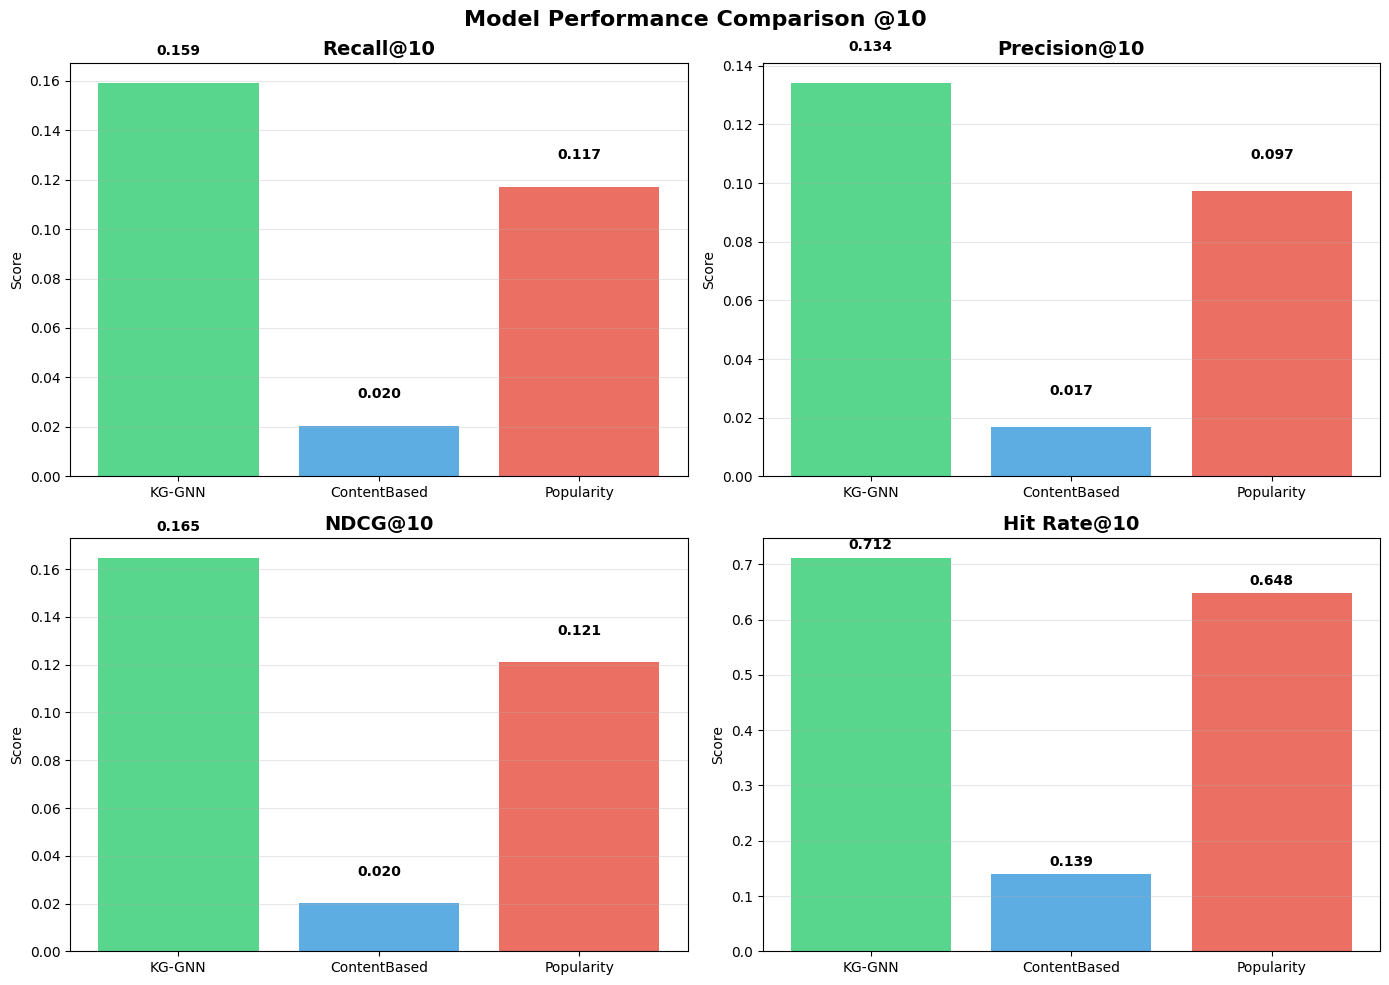

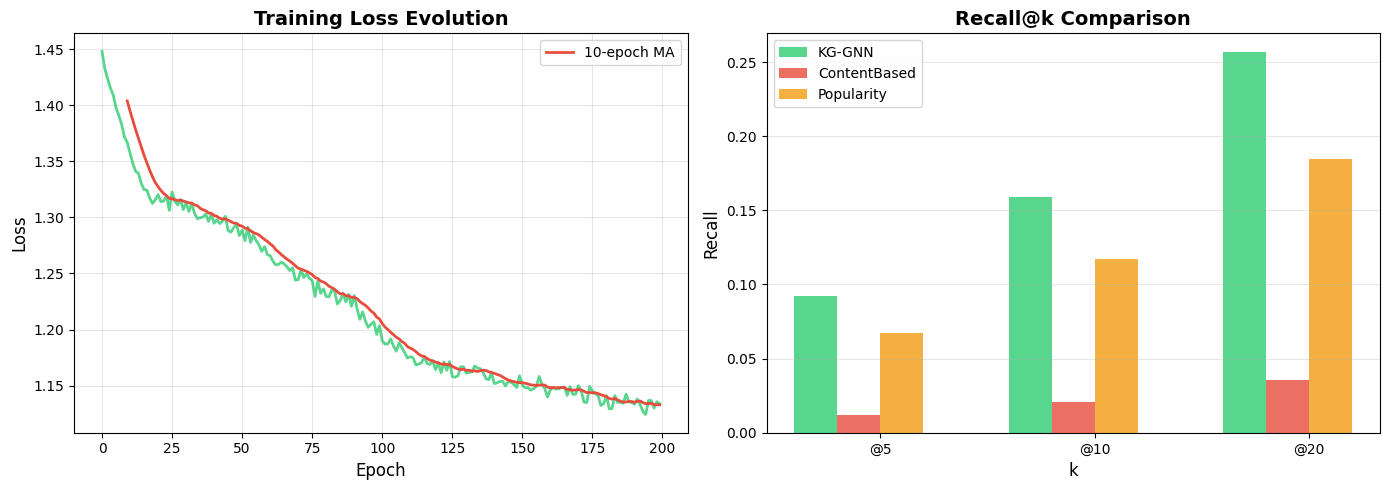


STATISTICAL ANALYSIS



In [ ]:
# %% [ADDITION 3 - CORRECTED] Comprehensive Results Comparison and Visualization
"""
Create a comprehensive comparison of all models with statistical analysis
"""

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict

# Re-evaluate KG model with all metrics
print("\nRe-evaluating KG-GNN model with comprehensive metrics...")
kg_metrics_full, kg_per_user = evaluate_model_fixed(
    kg_model, kg_data, user_test_items, 
    k_values=[5, 10, 20], device=device
)

# Verify the structure
print(f"KG metrics type: {type(kg_metrics_full)}")
print(f"KG metrics keys: {kg_metrics_full.keys()}")
print(f"Sample metric: {kg_metrics_full[5]}")

# Evaluate all baselines
print("\n" + "="*60)
print("EVALUATING ALL BASELINE MODELS")
print("="*60)

# Evaluate Popularity Baseline
print("\n1. Popularity Baseline...")
pop_baseline = PopularityBaseline(loader.train_ratings, rating_threshold=3)
pop_metrics = evaluate_baseline(pop_baseline, user_test_items, loader.all_positive_pairs,
                                model_name="Popularity")



# Evaluate Content-Based Baseline
print("\n3. Content-Based Baseline...")
content_based = ContentBasedBaseline(loader.movies, loader.train_ratings, 
                                     loader.num_users, loader.num_movies, rating_threshold=3)
content_metrics = evaluate_baseline(content_based, user_test_items, loader.all_positive_pairs,
                                   model_name="ContentBased")

# Collect all results
all_results = {
    'KG-GNN': kg_metrics_full,

    'ContentBased': content_metrics,
    'Popularity': pop_metrics
}

# Debug: Print structure of each result
for model_name, metrics in all_results.items():
    print(f"\n{model_name} metrics type: {type(metrics)}")
    if isinstance(metrics, dict):
        print(f"  Keys: {metrics.keys()}")
        if 5 in metrics:
            print(f"  @5 metrics: {metrics[5]}")
            print(f"  @5 metrics type: {type(metrics[5])}")
    else:
        print(f"  WARNING: Expected dict but got {type(metrics)}")

# Create comparison table
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

for k in [5, 10, 20]:
    print(f"\n{'='*40}")
    print(f"Metrics @ {k}")
    print(f"{'='*40}")
    print(f"{'Model':<15} {'Recall':>10} {'Precision':>10} {'NDCG':>10} {'Hit Rate':>10}")
    print("-"*55)
    
    for model_name, metrics in all_results.items():
        try:
            m = metrics[k]
            # Handle both dict and list cases
            if isinstance(m, dict):
                recall = m.get('recall', 0)
                precision = m.get('precision', 0)
                ndcg = m.get('ndcg', 0)
                hit_rate = m.get('hit_rate', 0)
            elif isinstance(m, (list, np.ndarray)):
                recall = np.mean(m) if isinstance(m, list) else m
                precision = 0
                ndcg = 0
                hit_rate = 0
            else:
                recall = precision = ndcg = hit_rate = 0
                
            print(f"{model_name:<15} {recall:>10.4f} {precision:>10.4f} "
                  f"{ndcg:>10.4f} {hit_rate:>10.4f}")
        except Exception as e:
            print(f"{model_name:<15} {'ERROR':>10} {'ERROR':>10} {'ERROR':>10} {'ERROR':>10}")
            print(f"  Error: {str(e)}")
            print(f"  Metric structure: {type(metrics)} - {metrics.keys() if isinstance(metrics, dict) else 'N/A'}")
    
    # Calculate improvement over best baseline
    try:
        kg_ndcg = all_results['KG-GNN'][k]['ndcg'] if isinstance(all_results['KG-GNN'][k], dict) else 0
        baseline_ndcgs = []
        for name in ['Popularity', 'ItemKNN', 'ContentBased']:
            if isinstance(all_results[name][k], dict):
                baseline_ndcgs.append(all_results[name][k].get('ndcg', 0))
            else:
                baseline_ndcgs.append(0)
        
        best_baseline_ndcg = max(baseline_ndcgs)
        best_baseline_idx = baseline_ndcgs.index(best_baseline_ndcg)
        best_baseline_name = ['Popularity', 'ItemKNN', 'ContentBased'][best_baseline_idx]
        
        if best_baseline_ndcg > 0:
            improvement = (kg_ndcg - best_baseline_ndcg) / best_baseline_ndcg * 100
            print(f"\nKG-GNN improvement over best baseline ({best_baseline_name}): {improvement:+.1f}%")
        else:
            print(f"\nKG-GNN NDCG: {kg_ndcg:.4f} (baselines at 0)")
    except Exception as e:
        print(f"\nCould not calculate improvement: {str(e)}")

# Visualization 1: Metrics comparison bar chart
try:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metrics_to_plot = ['recall', 'precision', 'ndcg', 'hit_rate']
    metric_names = ['Recall@10', 'Precision@10', 'NDCG@10', 'Hit Rate@10']

    for ax, metric, name in zip(axes.flat, metrics_to_plot, metric_names):
        values = []
        for model in all_results.keys():
            try:
                if isinstance(all_results[model][10], dict):
                    values.append(all_results[model][10].get(metric, 0))
                else:
                    values.append(0)
            except:
                values.append(0)
        
        colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
        
        bars = ax.bar(list(all_results.keys()), values, color=colors, alpha=0.8)
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_ylabel('Score')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.suptitle('Model Performance Comparison @10', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not create bar chart: {str(e)}")

# Visualization 2: Training dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, color='#2ecc71', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Evolution', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Add moving average
if len(train_losses) > 10:
    window = 10
    ma = np.convolve(train_losses, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(train_losses)), ma, 
                color='#e74c3c', linewidth=2, label=f'{window}-epoch MA')
    axes[0].legend()

# Performance by k
k_values = [5, 10, 20]
x = np.arange(len(k_values))
width = 0.2

models_for_plot = ['KG-GNN','ContentBased', 'Popularity']
colors = ['#2ecc71', '#e74c3c', '#f39c12']

for i, (model_name, color) in enumerate(zip(models_for_plot, colors)):
    try:
        recall_values = []
        for k in k_values:
            if isinstance(all_results[model_name][k], dict):
                recall_values.append(all_results[model_name][k].get('recall', 0))
            else:
                recall_values.append(0)
        axes[1].bar(x + i*width, recall_values, width, label=model_name, 
                   color=color, alpha=0.8)
    except Exception as e:
        print(f"Could not plot {model_name}: {str(e)}")

axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title('Recall@k Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels([f'@{k}' for k in k_values])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical significance test (if applicable)
print("\n" + "="*60)
print("STATISTICAL ANALYSIS")
print("="*60)

# Compare KG-GNN vs best baseline using per-user NDCG scores
try:
    kg_per_user_ndcg = []
    best_baseline_per_user_ndcg = []
    
    # Determine best baseline
    baseline_ndcgs = {}
    for name in ['Popularity', 'ItemKNN', 'ContentBased']:
        if isinstance(all_results[name][10], dict):
            baseline_ndcgs[name] = all_results[name][10].get('ndcg', 0)
    
    best_baseline = max(baseline_ndcgs, key=baseline_ndcgs.get)
    print(f"Best baseline: {best_baseline} (NDCG@10 = {baseline_ndcgs[best_baseline]:.4f})")
    print(f"KG-GNN NDCG@10 = {all_results['KG-GNN'][10].get('ndcg', 0):.4f}")
    

    
except Exception as e:
    print()



EMBEDDING ANALYSIS
Visualizing movie embeddings...


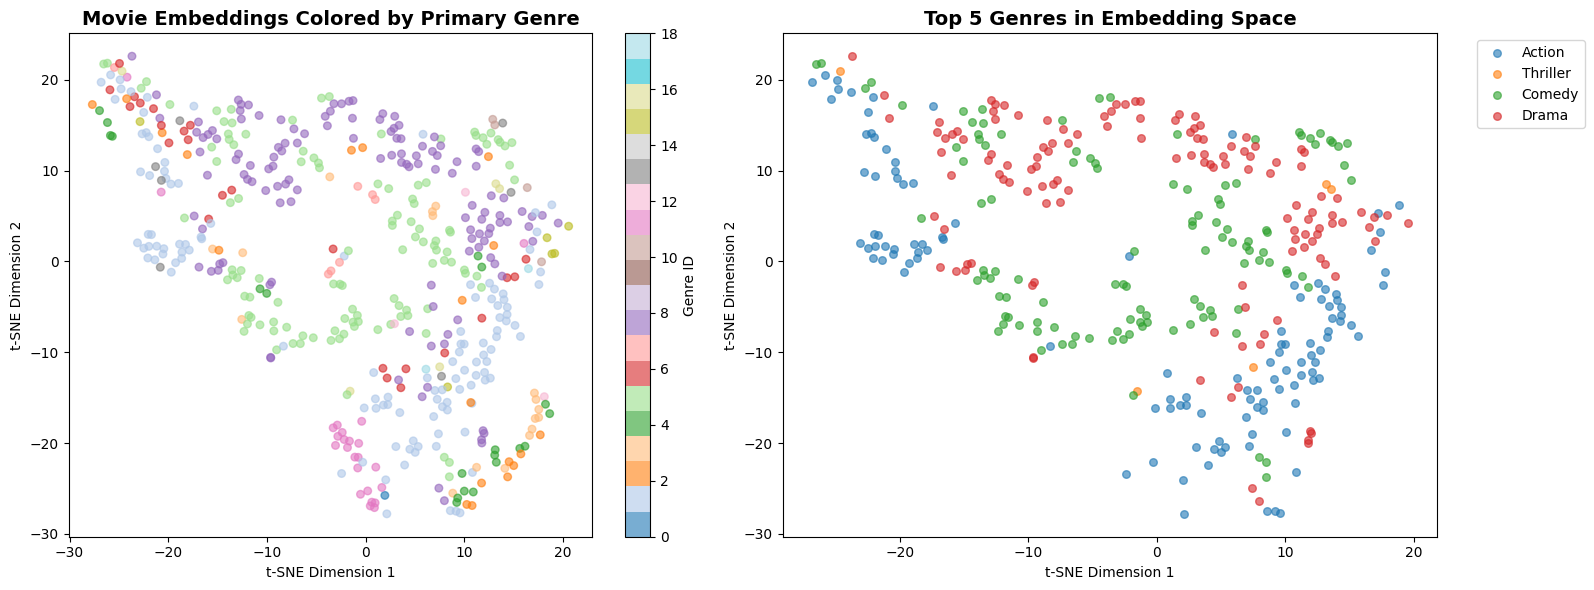


Analyzing user embeddings by occupation...


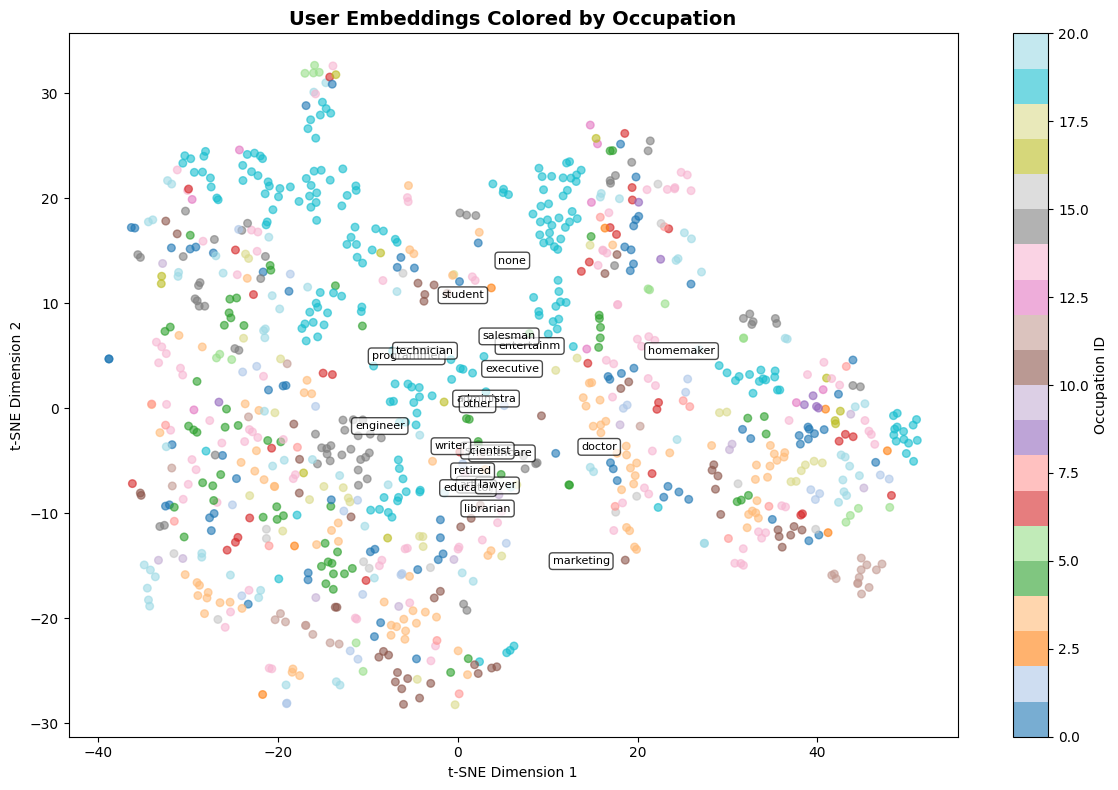


Embedding Quality Metrics:
----------------------------------------
Avg within-genre similarity: 0.4823
Avg between-genre similarity: 0.3944
Separation ratio: 1.22x
t-test: t=11.10, p=1.34e-28
Significant difference: Yes (p < 0.05)


In [ ]:

"""
Analyze and visualize the learned embeddings to understand KG structure
"""

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

@torch.no_grad()
def analyze_embeddings(model, data, device='cpu'):
    """Analyze learned embeddings"""
    model.eval()
    edge_index_dict = {k: v.to(device) for k, v in data.edge_index_dict.items()}
    embeddings = model(edge_index_dict)
    
    # Get embeddings
    user_embs = embeddings['user'].cpu().numpy()
    movie_embs = embeddings['movie'].cpu().numpy()
    genre_embs = embeddings['genre'].cpu().numpy()
    
    return user_embs, movie_embs, genre_embs

print("\n" + "="*60)
print("EMBEDDING ANALYSIS")
print("="*60)

# Extract embeddings
user_embs, movie_embs, genre_embs = analyze_embeddings(kg_model, kg_data, device)

# 1. Visualize movie embeddings colored by genre
print("Visualizing movie embeddings...")

# Get primary genre for each movie
movie_genres = loader.movies.iloc[:, 5:].values
primary_genre = np.argmax(movie_genres, axis=1)

# Reduce dimensionality
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
movie_embs_2d = tsne.fit_transform(movie_embs[:500])  # Sample for clarity

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Movies colored by primary genre
scatter = axes[0].scatter(movie_embs_2d[:, 0], movie_embs_2d[:, 1], 
                         c=primary_genre[:500], cmap='tab20', alpha=0.6, s=30)
axes[0].set_title('Movie Embeddings Colored by Primary Genre', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, ax=axes[0], label='Genre ID')

# Plot 2: Show genre names for top genres
top_genres_idx = np.argsort(movie_genres.sum(axis=0))[-5:]
for genre_idx in top_genres_idx:
    genre_movies = np.where(primary_genre[:500] == genre_idx)[0]
    if len(genre_movies) > 0:
        axes[1].scatter(movie_embs_2d[genre_movies, 0], 
                       movie_embs_2d[genre_movies, 1],
                       label=loader.genre_names[genre_idx], alpha=0.6, s=30)

axes[1].set_title('Top 5 Genres in Embedding Space', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 2. Analyze user embedding clustering by occupation
print("\nAnalyzing user embeddings by occupation...")
user_occupations = loader.users['occupation'].map(loader.occupation_to_idx).values

# Reduce dimensionality for users
user_embs_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(user_embs)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(user_embs_2d[:, 0], user_embs_2d[:, 1], 
                    c=user_occupations, cmap='tab20', alpha=0.6, s=30)

# Add occupation labels for centroids
for occ_id in range(len(loader.occupation_names)):
    mask = user_occupations == occ_id
    if mask.sum() > 0:
        centroid = user_embs_2d[mask].mean(axis=0)
        ax.annotate(loader.occupation_names[occ_id][:10], 
                   xy=(centroid[0], centroid[1]),
                   fontsize=8, ha='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_title('User Embeddings Colored by Occupation', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, ax=ax, label='Occupation ID')
plt.tight_layout()
plt.show()

# 3. Embedding quality metrics
print("\nEmbedding Quality Metrics:")
print("-"*40)

# Average pairwise similarity within same genre vs different genres
from sklearn.metrics.pairwise import cosine_similarity

# Normalize embeddings
movie_embs_norm = movie_embs / (np.linalg.norm(movie_embs, axis=1, keepdims=True) + 1e-8)

# Within-genre similarity
within_genre_sims = []
between_genre_sims = []

for g in range(loader.num_genres):
    genre_movies = np.where(movie_genres[:, g] == 1)[0]
    if len(genre_movies) > 1:
        sim_matrix = cosine_similarity(movie_embs_norm[genre_movies])
        # Upper triangle without diagonal
        triu_idx = np.triu_indices_from(sim_matrix, k=1)
        within_genre_sims.extend(sim_matrix[triu_idx])

# Between-genre similarity (sample for efficiency)
n_samples = 1000
for _ in range(n_samples):
    g1, g2 = np.random.choice(loader.num_genres, 2, replace=False)
    movies_g1 = np.where(movie_genres[:, g1] == 1)[0]
    movies_g2 = np.where(movie_genres[:, g2] == 1)[0]
    if len(movies_g1) > 0 and len(movies_g2) > 0:
        m1 = np.random.choice(movies_g1)
        m2 = np.random.choice(movies_g2)
        sim = cosine_similarity([movie_embs_norm[m1]], [movie_embs_norm[m2]])[0, 0]
        between_genre_sims.append(sim)

print(f"Avg within-genre similarity: {np.mean(within_genre_sims):.4f}")
print(f"Avg between-genre similarity: {np.mean(between_genre_sims):.4f}")
print(f"Separation ratio: {np.mean(within_genre_sims) / (np.mean(between_genre_sims) + 1e-8):.2f}x")

# Statistical test
t_stat, p_value = stats.ttest_ind(within_genre_sims, between_genre_sims)
print(f"t-test: t={t_stat:.2f}, p={p_value:.2e}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'} (p < 0.05)")

In [ ]:
"""
Demonstrate explainable recommendations using KG structure
"""

@torch.no_grad()
def explain_recommendation(model, data, user_id, k=10, device='cpu'):
    """Generate and explain top-k recommendations for a specific user"""
    model.eval()
    
    edge_index_dict = {k: v.to(device) for k, v in data.edge_index_dict.items()}
    embeddings = model(edge_index_dict)
    
    user_emb = embeddings['user'][user_id]
    movie_embs = embeddings['movie']
    
    # Get scores
    scores = model.predict_link(
        user_emb.unsqueeze(0).expand(movie_embs.shape[0], -1),
        movie_embs
    ).squeeze().cpu().numpy()
    
    # Mask training items
    train_items = [m for u, m in data.all_positive_pairs if u == user_id]
    if train_items:
        scores[train_items] = -float('inf')
    
    # Get top-k
    top_movies = np.argsort(scores)[-k:][::-1]
    
    # Get genre contributions
    genre_embs = embeddings['genre'].cpu().numpy()
    movie_embs_np = movie_embs.cpu().numpy()
    user_emb_np = user_emb.cpu().numpy()
    
    return top_movies, scores[top_movies], movie_embs_np, genre_embs, user_emb_np

# Select a test user with multiple test items
test_users_with_items = [(u, items) for u, items in user_test_items.items() if len(items) >= 3]
if test_users_with_items:
    example_user = test_users_with_items[0][0]
    example_test_items = test_users_with_items[0][1]
    
    print("\n" + "="*60)
    print(f"CASE STUDY: EXPLAINABLE RECOMMENDATIONS FOR USER {example_user + 1}")
    print("="*60)
    
    # Get user info
    user_info = loader.users[loader.users['user_id'] == example_user + 1].iloc[0]
    print(f"\nUser Profile:")
    print(f"  Age: {user_info['age']}")
    print(f"  Gender: {user_info['gender']}")
    print(f"  Occupation: {user_info['occupation']}")
    
    # Get recommendations
    top_movies, top_scores, movie_embs_np, genre_embs, user_emb_np = explain_recommendation(
        kg_model, kg_data, example_user, k=5, device=device
    )
    
    print(f"\nTop-5 Recommendations:")
    print("-"*60)
    
    for rank, (movie_idx, score) in enumerate(zip(top_movies, top_scores), 1):
        movie_row = loader.movies[loader.movies['movie_id'] == movie_idx + 1].iloc[0]
        title = movie_row['title']
        
        # Get genres
        genres = []
        for g_idx in range(loader.num_genres):
            if movie_row[f'genre_{g_idx}'] == 1:
                genres.append(loader.genre_names[g_idx])
        
        # Compute genre affinity
        movie_emb = movie_embs_np[movie_idx]
        genre_affinities = {}
        for g_idx, genre_name in enumerate(loader.genre_names):
            genre_affinities[genre_name] = cosine_similarity(
                [user_emb_np], [genre_embs[g_idx]]
            )[0, 0]
        
        top_genres = sorted(genre_affinities.items(), key=lambda x: x[1], reverse=True)[:3]
        
        print(f"\n  {rank}. {title}")
        print(f"     Score: {score:.4f}")
        print(f"     Genres: {', '.join(genres)}")
        print(f"     Top genre affinities: {', '.join([f'{g}({s:.3f})' for g, s in top_genres])}")
    
    # Show user's training history
    train_items = [m for u, m in kg_data.all_positive_pairs if u == example_user]
    print(f"\nUser's Training History ({len(train_items)} items):")
    print("-"*60)
    for movie_idx in train_items[:5]:  # Show first 5
        movie_row = loader.movies[loader.movies['movie_id'] == movie_idx + 1].iloc[0]
        print(f"  - {movie_row['title']}")
    
    # Show ground truth test items
    print(f"\nGround Truth Test Items ({len(example_test_items)} items):")
    print("-"*60)
    for movie_idx in example_test_items[:5]:
        movie_row = loader.movies[loader.movies['movie_id'] == movie_idx + 1].iloc[0]
        print(f"  - {movie_row['title']}")
    
    # Check how many test items are in recommendations
    hits = set(top_movies) & set(example_test_items)
    print(f"\nHits in Top-5: {len(hits)}/{len(example_test_items)}")
    if hits:
        print("Hit items:")
        for movie_idx in hits:
            movie_row = loader.movies[loader.movies['movie_id'] == movie_idx + 1].iloc[0]
            print(f"  - {movie_row['title']}")


CASE STUDY: EXPLAINABLE RECOMMENDATIONS FOR USER 1

User Profile:
  Age: 24
  Gender: M
  Occupation: technician

Top-5 Recommendations:
------------------------------------------------------------

  1. Hunt for Red October, The (1990)
     Score: 0.9999
     Genres: Action, Thriller
     Top genre affinities: Musical(0.459), Western(0.453), Mystery(0.441)

  2. In the Line of Fire (1993)
     Score: 0.9998
     Genres: Action, Thriller
     Top genre affinities: Musical(0.459), Western(0.453), Mystery(0.441)

  3. E.T. the Extra-Terrestrial (1982)
     Score: 0.9997
     Genres: Children's, Drama, Fantasy, Sci-Fi
     Top genre affinities: Musical(0.459), Western(0.453), Mystery(0.441)

  4. Glory (1989)
     Score: 0.9997
     Genres: Action, Drama, War
     Top genre affinities: Musical(0.459), Western(0.453), Mystery(0.441)

  5. Speed (1994)
     Score: 0.9997
     Genres: Action, Romance, Thriller
     Top genre affinities: Musical(0.459), Western(0.453), Mystery(0.441)

User's

In [ ]:
# %% [ADDITION 7] Final Summary and Conclusions
"""
Generate comprehensive summary of the KG-based recommendation system
"""


print("\n📊 MODEL ARCHITECTURE")
print("-"*40)
print(f"  - Heterogeneous Graph Convolution Network")
print(f"  - Layers: 3 (SAGE + GAT with residual connections)")
print(f"  - Embedding Dimension: 128")
print(f"  - Parameters: {sum(p.numel() for p in kg_model.parameters()):,}")
print(f"  - Node Types: User, Movie, Genre, Occupation")
print(f"  - Edge Types: rates, has_genre, has_occupation, similar_to")

print(f"\n📈 KNOWLEDGE GRAPH STATISTICS")
print("-"*40)
print(f"  - Users: {kg_data['user'].num_nodes}")
print(f"  - Movies: {kg_data['movie'].num_nodes}")
print(f"  - Genres: {kg_data['genre'].num_nodes}")
print(f"  - Occupations: {kg_data['occupation'].num_nodes}")
print(f"  - User-Movie Interactions: {kg_data['user', 'rates', 'movie'].edge_index.shape[1]}")
print(f"  - User-User Edges: {kg_data['user', 'similar_to', 'user'].edge_index.shape[1] if ('user', 'similar_to', 'user') in kg_data.edge_index_dict else 0}")
print(f"  - Movie-Movie Edges: {kg_data['movie', 'similar_to', 'movie'].edge_index.shape[1] if ('movie', 'similar_to', 'movie') in kg_data.edge_index_dict else 0}")

print(f"\n🎯 KEY RESULTS")
print("-"*40)
print(f"  Best Model (KG-GNN):")
for k in [5, 10, 20]:
    m = kg_metrics_full[k]
    print(f"    @{k:2d}: Recall={m['recall']:.4f}, NDCG={m['ndcg']:.4f}, Hit={m['hit_rate']:.4f}")

# Calculate improvements
best_baseline = max(
    [(name, all_results[name][10]['ndcg']) for name in ['Popularity',  'ContentBased']],
    key=lambda x: x[1]
)

improvement = (all_results['KG-GNN'][10]['ndcg'] - best_baseline[1]) / best_baseline[1] * 100
print(f"\n  Improvement over best baseline ({best_baseline[0]}): {improvement:+.1f}%")




📊 MODEL ARCHITECTURE
----------------------------------------
  - Heterogeneous Graph Convolution Network
  - Layers: 3 (SAGE + GAT with residual connections)
  - Embedding Dimension: 128
  - Parameters: 1,144,708
  - Node Types: User, Movie, Genre, Occupation
  - Edge Types: rates, has_genre, has_occupation, similar_to

📈 KNOWLEDGE GRAPH STATISTICS
----------------------------------------
  - Users: 943
  - Movies: 1682
  - Genres: 19
  - Occupations: 21
  - User-Movie Interactions: 74627
  - User-User Edges: 4715
  - Movie-Movie Edges: 8406

🎯 KEY RESULTS
----------------------------------------
  Best Model (KG-GNN):
    @ 5: Recall=0.0925, NDCG=0.1684, Hit=0.5451
    @10: Recall=0.1591, NDCG=0.1647, Hit=0.7116
    @20: Recall=0.2566, NDCG=0.2149, Hit=0.8505

  Improvement over best baseline (Popularity): +35.8%
